<a href="https://colab.research.google.com/github/7amzaGH/TUBLEX-Bubble-Plume-Analysis/blob/main/notebooks/03_TUBLEX_RF_vs_XGBoost_Holdout_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUBLEX RF vs XGBoost Hold-Out Comparison

**Repository:** [TUBLEX-Bubble-Plume-Analysis](https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis)

This notebook compares the saved Random Forest and XGBoost models on the same video-level hold-out test set.

The goal is to provide a fair model comparison using:

- the same cleaned TUBLEX dataset
- the same 11 bubble descriptor features
- the same video-level split
- the same hold-out test samples
- the same evaluation metrics

No model is retrained in this notebook. Both models are loaded from saved `.joblib` files and evaluated on the shared test set.

In [1]:
# ============================================================
# CLONE TUBLEX GITHUB REPOSITORY
# ============================================================

import os
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis.git"
REPO_NAME = "TUBLEX-Bubble-Plume-Analysis"

# In Google Colab, clone the public repository and enter it.
# Locally, the notebook can also be run directly from the repository root.
if Path("/content").exists():
    os.chdir("/content")

    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)

    os.chdir(REPO_NAME)
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

print("Project root:", PROJECT_ROOT)


Project root: /content/TUBLEX-Bubble-Plume-Analysis


In [2]:
# ============================================================
# INSTALL REQUIREMENTS
# ============================================================

import sys
import subprocess
from pathlib import Path

requirements_path = PROJECT_ROOT / "requirements.txt"

# Temporary fallback in case an older local copy still contains the misspelled file.
if not requirements_path.exists():
    fallback_path = PROJECT_ROOT / "requirments.txt"
    if fallback_path.exists():
        requirements_path = fallback_path

if requirements_path.exists():
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirements_path),
    ])
    print("Installed requirements from:", requirements_path)
else:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "numpy",
        "pandas",
        "matplotlib",
        "scikit-learn",
        "joblib",
        "xgboost",
    ])
    print("requirements.txt not found. Installed minimal dependencies.")


Installed requirements from: /content/TUBLEX-Bubble-Plume-Analysis/requirements.txt


In [3]:
# ============================================================
# IMPORTS AND REPOSITORY PATHS
# ============================================================

import json
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")

try:
    import xgboost
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    import xgboost


def resolve_existing_path(primary_path, fallback_path=None):
    """Return primary_path if it exists, otherwise return fallback_path if available."""
    primary_path = Path(primary_path)

    if primary_path.exists():
        return primary_path

    if fallback_path is not None:
        fallback_path = Path(fallback_path)
        if fallback_path.exists():
            return fallback_path

    return primary_path


DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tublex_window_features.csv"
METADATA_PATH = PROJECT_ROOT / "data" / "metadata" / "tublex_video_metadata.csv"
SPLIT_PATH = PROJECT_ROOT / "data" / "splits" / "tublex_video_level_split_seed42.csv"

RF_MODEL_PATH = resolve_existing_path(
    PROJECT_ROOT / "models" / "random_forest" / "rf_tublex_final.joblib",
    PROJECT_ROOT / "models" / "Random_Forest_tublex" / "rf_tublex_final.joblib",
)

XGB_MODEL_PATH = resolve_existing_path(
    PROJECT_ROOT / "models" / "xgboost" / "xgb_tublex_final.joblib",
    PROJECT_ROOT / "models" / "Xgboost_tublex" / "xgb_tublex_final.joblib",
)

RF_METADATA_PATH = resolve_existing_path(
    PROJECT_ROOT / "models" / "random_forest" / "rf_tublex_metadata.json",
    PROJECT_ROOT / "models" / "Random_Forest_tublex" / "rf_tublex_metadata.json",
)

XGB_METADATA_PATH = resolve_existing_path(
    PROJECT_ROOT / "models" / "xgboost" / "xgb_tublex_metadata.json",
    PROJECT_ROOT / "models" / "Xgboost_tublex" / "xgb_tublex_metadata.json",
)

OUTPUT_DIR = PROJECT_ROOT / "results" / "model_comparison"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

RF_TABLE_DIR = PROJECT_ROOT / "results" / "selected_model_rf" / "tables"
XGB_TABLE_DIR = PROJECT_ROOT / "results" / "xgboost_baseline" / "tables"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH)
print("Metadata:", METADATA_PATH)
print("Split:", SPLIT_PATH)
print("RF model:", RF_MODEL_PATH)
print("XGBoost model:", XGB_MODEL_PATH)
print("RF metadata:", RF_METADATA_PATH)
print("XGBoost metadata:", XGB_METADATA_PATH)
print("Output tables:", TABLE_DIR)
print("Output figures:", FIGURE_DIR)


Dataset: /content/TUBLEX-Bubble-Plume-Analysis/data/processed/tublex_window_features.csv
Metadata: /content/TUBLEX-Bubble-Plume-Analysis/data/metadata/tublex_video_metadata.csv
Split: /content/TUBLEX-Bubble-Plume-Analysis/data/splits/tublex_video_level_split_seed42.csv
RF model: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_final.joblib
XGBoost model: /content/TUBLEX-Bubble-Plume-Analysis/models/xgboost/xgb_tublex_final.joblib
RF metadata: /content/TUBLEX-Bubble-Plume-Analysis/models/random_forest/rf_tublex_metadata.json
XGBoost metadata: /content/TUBLEX-Bubble-Plume-Analysis/models/xgboost/xgb_tublex_metadata.json
Output tables: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables
Output figures: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/figures


In [4]:
# ============================================================
# LOAD DATASET, SPLIT, MODEL METADATA, AND MODELS
# ============================================================

def load_model_metadata(metadata_path):
    """Load fixed model metadata or an old feature-list JSON."""
    with open(metadata_path, "r", encoding="utf-8") as f:
        metadata = json.load(f)

    if isinstance(metadata, list):
        metadata = {
            "model_name": "Unknown",
            "model_type": "Unknown",
            "positive_class": 1,
            "decision_threshold": 0.5,
            "feature_columns": metadata,
        }

    required_keys = [
        "model_name",
        "model_type",
        "positive_class",
        "decision_threshold",
        "feature_columns",
    ]

    missing = [key for key in required_keys if key not in metadata]

    if missing:
        raise ValueError(f"Missing metadata keys in {metadata_path}: {missing}")

    return metadata


df = pd.read_csv(DATA_PATH)
metadata_df = pd.read_csv(METADATA_PATH)
split_df = pd.read_csv(SPLIT_PATH)

rf_metadata = load_model_metadata(RF_METADATA_PATH)
xgb_metadata = load_model_metadata(XGB_METADATA_PATH)

rf_features = rf_metadata["feature_columns"]
xgb_features = xgb_metadata["feature_columns"]

if set(rf_features) != set(xgb_features):
    raise ValueError("RF and XGBoost do not use the same feature set.")

if rf_features != xgb_features:
    print("Note: RF and XGBoost use the same feature set but a different feature order.")
    print("Each model will be evaluated using its own saved metadata order.")

rf_model = joblib.load(RF_MODEL_PATH)
xgb_model = joblib.load(XGB_MODEL_PATH)

print("=" * 70)
print("LOADED COMPARISON INPUTS")
print("=" * 70)

print("Dataset shape:", df.shape)
print("Metadata shape:", metadata_df.shape)
print("Split shape:", split_df.shape)
print("Number of RF features:", len(rf_features))
print("Number of XGBoost features:", len(xgb_features))

print("\nRF model:", rf_metadata["model_name"])
print("XGBoost model:", xgb_metadata["model_name"])

print("\nModels loaded successfully.")


LOADED COMPARISON INPUTS
Dataset shape: (2504, 15)
Metadata shape: (85, 8)
Split shape: (85, 2)
Number of RF features: 11
Number of XGBoost features: 11

RF model: TUBLEX Model
XGBoost model: TUBLEX XGBoost

Models loaded successfully.


In [5]:
# ============================================================
# RECONSTRUCT HOLD-OUT TEST SET
# ============================================================

train_videos = set(split_df.loc[split_df["split"] == "train", "source_video_id"])
test_videos = set(split_df.loc[split_df["split"] == "test", "source_video_id"])

assert train_videos.isdisjoint(test_videos), "Train and test videos overlap."

test_df = df[df["source_video_id"].isin(test_videos)].copy()

# Stable ordering for reproducible comparison.
test_df = test_df.sort_values("sample_id").reset_index(drop=True)

X_test_rf = test_df[rf_features]
X_test_xgb = test_df[xgb_features]
y_test = test_df["label"]

test_report = test_df.merge(metadata_df, on="source_video_id", how="left")

split_summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Videos": [len(train_videos), len(test_videos)],
    "Windows": [
        int(df["source_video_id"].isin(train_videos).sum()),
        int(df["source_video_id"].isin(test_videos).sum()),
    ],
    "Leak": [
        int(((df["source_video_id"].isin(train_videos)) & (df["label"] == 1)).sum()),
        int(((df["source_video_id"].isin(test_videos)) & (df["label"] == 1)).sum()),
    ],
    "Non-Leak": [
        int(((df["source_video_id"].isin(train_videos)) & (df["label"] == 0)).sum()),
        int(((df["source_video_id"].isin(test_videos)) & (df["label"] == 0)).sum()),
    ],
})

split_summary_path = TABLE_DIR / "comparison_split_summary.csv"
split_summary.to_csv(split_summary_path, index=False)

display(split_summary)

print("Saved:", split_summary_path)
print("Test rows:", len(test_df))
print("Test videos:", test_df["source_video_id"].nunique())


,Split,Videos,Windows,Leak,Non-Leak
0,Train,68,2009,999,1010
1,Test,17,495,253,242


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables/comparison_split_summary.csv
Test rows: 495
Test videos: 17


In [6]:
# ============================================================
# RUN SAVED MODELS ON HOLD-OUT TEST SET
# ============================================================

rf_pred = rf_model.predict(X_test_rf)
rf_prob = rf_model.predict_proba(X_test_rf)[:, 1]

xgb_pred = xgb_model.predict(X_test_xgb)
xgb_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

comparison_predictions = test_df[["sample_id", "source_video_id", "window_id", "label"]].copy()

if "time_sec" in test_df.columns:
    comparison_predictions["time_sec"] = test_df["time_sec"]

comparison_predictions["rf_predicted_label"] = rf_pred
comparison_predictions["rf_leak_probability"] = rf_prob

comparison_predictions["xgboost_predicted_label"] = xgb_pred
comparison_predictions["xgboost_leak_probability"] = xgb_prob

comparison_predictions = comparison_predictions.merge(metadata_df, on="source_video_id", how="left")

prediction_path = TABLE_DIR / "holdout_model_predictions.csv"
comparison_predictions.to_csv(prediction_path, index=False)

display(comparison_predictions.head())

print("Saved:", prediction_path)


,sample_id,source_video_id,window_id,label,rf_predicted_label,rf_leak_probability,xgboost_predicted_label,xgboost_leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1
0,L_G12_PSI05_V001_W0000,L_G12_PSI05_V001,0,0,0,0.00,0,0.000543,G12_PSI05,leak,12,5,40,8,32
1,L_G12_PSI05_V001_W0001,L_G12_PSI05_V001,1,0,0,0.00,0,0.002179,G12_PSI05,leak,12,5,40,8,32
2,L_G12_PSI05_V001_W0002,L_G12_PSI05_V001,2,0,0,0.00,0,0.000765,G12_PSI05,leak,12,5,40,8,32
3,L_G12_PSI05_V001_W0003,L_G12_PSI05_V001,3,0,0,0.01,0,0.000782,G12_PSI05,leak,12,5,40,8,32
4,L_G12_PSI05_V001_W0004,L_G12_PSI05_V001,4,0,0,0.00,0,0.000679,G12_PSI05,leak,12,5,40,8,32


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables/holdout_model_predictions.csv


In [7]:
# ============================================================
# FINAL HOLD-OUT METRIC COMPARISON
# ============================================================

def compute_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
    }


rf_metrics = compute_metrics(y_test, rf_pred, rf_prob)
xgb_metrics = compute_metrics(y_test, xgb_pred, xgb_prob)

metrics_df = pd.DataFrame([
    {"Model": "Random Forest", **rf_metrics},
    {"Model": "XGBoost", **xgb_metrics},
])

metrics_display = metrics_df.copy()
metric_cols = [c for c in metrics_display.columns if c != "Model"]
metrics_display[metric_cols] = metrics_display[metric_cols].round(4)

metrics_path = TABLE_DIR / "holdout_metric_comparison.csv"
metrics_display.to_csv(metrics_path, index=False)

display(metrics_display)

print("Saved:", metrics_path)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.9939,0.996,0.9921,0.9941,0.9999,0.9999
1,XGBoost,0.9859,0.996,0.9763,0.9860,0.9998,0.9998


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables/holdout_metric_comparison.csv


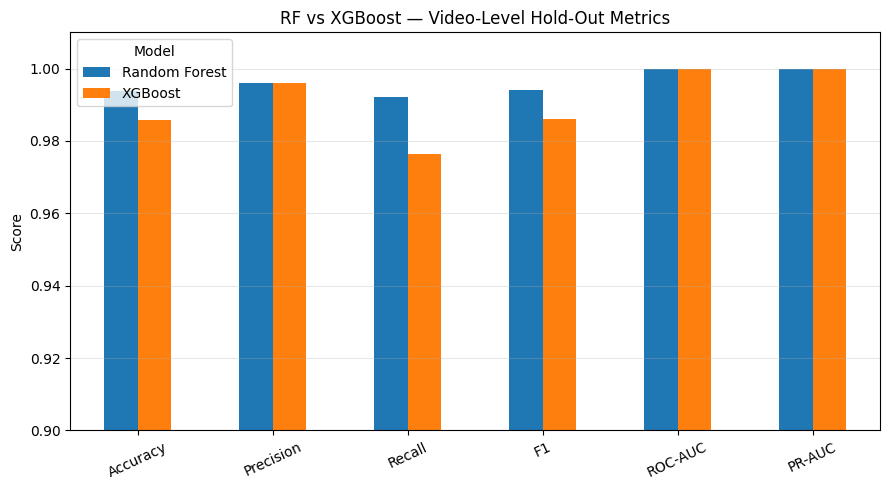

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/figures/holdout_metric_comparison.png


In [8]:
# ============================================================
# PLOT FINAL METRIC COMPARISON
# ============================================================

plot_df = metrics_display.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
]

ax = plot_df.T.plot(kind="bar", figsize=(9, 5), rot=25)

plt.title("RF vs XGBoost — Video-Level Hold-Out Metrics")
plt.ylabel("Score")
plt.ylim(0.90, 1.01)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

fig_path = FIGURE_DIR / "holdout_metric_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [9]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

print("=" * 70)
print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, rf_pred, target_names=["Non-Leak", "Leak"]))

print("=" * 70)
print("XGBOOST CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_test, xgb_pred, target_names=["Non-Leak", "Leak"]))


RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Non-Leak       0.99      1.00      0.99       242
        Leak       1.00      0.99      0.99       253

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495

XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Non-Leak       0.98      1.00      0.99       242
        Leak       1.00      0.98      0.99       253

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495



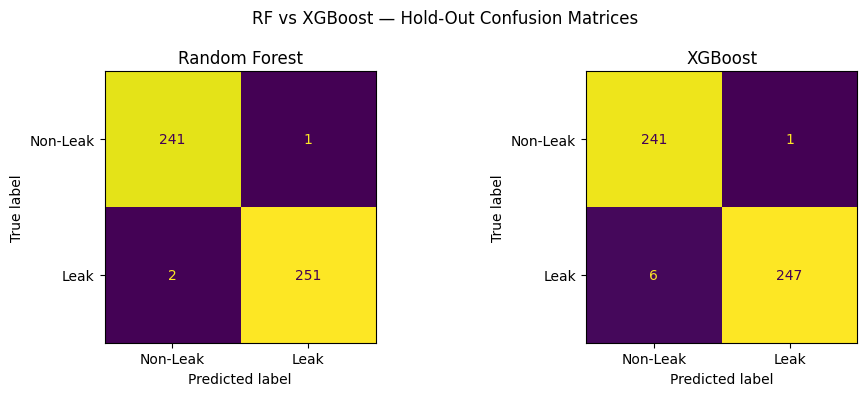

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/figures/holdout_confusion_matrices.png
RF confusion matrix:
 [[241   1]
 [  2 251]]
XGBoost confusion matrix:
 [[241   1]
 [  6 247]]


In [10]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

rf_cm = confusion_matrix(y_test, rf_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Non-Leak", "Leak"],
).plot(values_format="d", ax=axes[0], colorbar=False)

axes[0].set_title("Random Forest")

ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm,
    display_labels=["Non-Leak", "Leak"],
).plot(values_format="d", ax=axes[1], colorbar=False)

axes[1].set_title("XGBoost")

plt.suptitle("RF vs XGBoost — Hold-Out Confusion Matrices")
plt.tight_layout()

fig_path = FIGURE_DIR / "holdout_confusion_matrices.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print("RF confusion matrix:\n", rf_cm)
print("XGBoost confusion matrix:\n", xgb_cm)


In [12]:
# ============================================================
# PREDICTION AGREEMENT AND ERROR OVERLAP
# ============================================================

error_df = comparison_predictions.copy()

error_df["rf_correct"] = error_df["rf_predicted_label"] == error_df["label"]
error_df["xgboost_correct"] = error_df["xgboost_predicted_label"] == error_df["label"]


def error_group(row):
    if row["rf_correct"] and row["xgboost_correct"]:
        return "Both correct"

    if (not row["rf_correct"]) and (not row["xgboost_correct"]):
        return "Both wrong"

    if row["rf_correct"] and (not row["xgboost_correct"]):
        return "Only XGBoost wrong"

    if (not row["rf_correct"]) and row["xgboost_correct"]:
        return "Only RF wrong"

    return "Unknown"


error_df["comparison_group"] = error_df.apply(error_group, axis=1)

error_overlap = (
    error_df["comparison_group"]
    .value_counts()
    .reset_index()
)

error_overlap.columns = ["Comparison Group", "N Samples"]

error_overlap_path = TABLE_DIR / "holdout_error_overlap_summary.csv"
error_overlap.to_csv(error_overlap_path, index=False)

display(error_overlap)

print("Saved:", error_overlap_path)


,Comparison Group,N Samples
0,Both correct,488
1,Only XGBoost wrong,4
2,Both wrong,3


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables/holdout_error_overlap_summary.csv


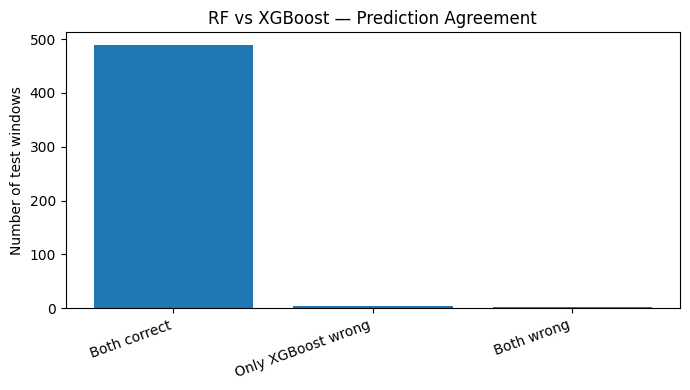

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/figures/holdout_error_overlap.png


In [13]:
# ============================================================
# PLOT ERROR OVERLAP
# ============================================================

plot_df = error_overlap.copy()

plt.figure(figsize=(7, 4))
plt.bar(plot_df["Comparison Group"], plot_df["N Samples"])

plt.title("RF vs XGBoost — Prediction Agreement")
plt.ylabel("Number of test windows")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

fig_path = FIGURE_DIR / "holdout_error_overlap.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [14]:
# ============================================================
# MODEL-SPECIFIC FAILURE CASES
# ============================================================

rf_only_errors = error_df[
    error_df["comparison_group"] == "Only RF wrong"
].copy()

xgb_only_errors = error_df[
    error_df["comparison_group"] == "Only XGBoost wrong"
].copy()

both_wrong = error_df[
    error_df["comparison_group"] == "Both wrong"
].copy()

rf_only_errors.to_csv(TABLE_DIR / "rf_only_errors.csv", index=False)
xgb_only_errors.to_csv(TABLE_DIR / "xgboost_only_errors.csv", index=False)
both_wrong.to_csv(TABLE_DIR / "both_models_wrong.csv", index=False)

print("RF-only errors:", len(rf_only_errors))
display(rf_only_errors.head(10))

print("\nXGBoost-only errors:", len(xgb_only_errors))
display(xgb_only_errors.head(10))

print("\nBoth models wrong:", len(both_wrong))
display(both_wrong.head(10))


RF-only errors: 0


,sample_id,source_video_id,window_id,label,rf_predicted_label,rf_leak_probability,xgboost_predicted_label,xgboost_leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1,rf_correct,xgboost_correct,comparison_group



XGBoost-only errors: 4


,sample_id,source_video_id,window_id,label,rf_predicted_label,rf_leak_probability,xgboost_predicted_label,xgboost_leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1,rf_correct,xgboost_correct,comparison_group
44,L_G14_PSI05_V001_W0004,L_G14_PSI05_V001,4,1,1,0.60,0,0.466440,G14_PSI05,leak,14,5,30,5,25,True,False,Only XGBoost wrong
118,L_G16_PSI22_V001_W0017,L_G16_PSI22_V001,17,1,1,0.84,0,0.347042,G16_PSI22,leak,16,22,26,7,19,True,False,Only XGBoost wrong
138,L_G18_PSI26_V001_W0013,L_G18_PSI26_V001,13,1,1,0.76,0,0.337606,G18_PSI26,leak,18,26,24,6,18,True,False,Only XGBoost wrong
254,L_G24_PSI30_V001_W0004,L_G24_PSI30_V001,4,1,1,0.60,0,0.449843,G24_PSI30,leak,24,30,45,1,44,True,False,Only XGBoost wrong



Both models wrong: 3


,sample_id,source_video_id,window_id,label,rf_predicted_label,rf_leak_probability,xgboost_predicted_label,xgboost_leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1,rf_correct,xgboost_correct,comparison_group
5,L_G12_PSI05_V001_W0005,L_G12_PSI05_V001,5,1,0,0.37,0,0.249757,G12_PSI05,leak,12,5,40,8,32,False,False,Both wrong
250,L_G24_PSI10_V001_W0046,L_G24_PSI10_V001,46,1,0,0.39,0,0.377801,G24_PSI10,leak,24,10,46,4,42,False,False,Both wrong
251,L_G24_PSI10_V001_W0047,L_G24_PSI10_V001,47,0,1,0.84,1,0.922361,G24_PSI10,leak,24,10,46,4,42,False,False,Both wrong


In [15]:
# ============================================================
# PROBABILITY DISAGREEMENT ANALYSIS
# ============================================================

error_df["probability_difference"] = (
    error_df["xgboost_leak_probability"] - error_df["rf_leak_probability"]
)

disagreement_df = error_df.copy()
disagreement_df["abs_probability_difference"] = disagreement_df[
    "probability_difference"
].abs()

disagreement_df = disagreement_df.sort_values(
    "abs_probability_difference",
    ascending=False,
)

disagreement_path = TABLE_DIR / "holdout_probability_disagreement.csv"
disagreement_df.to_csv(disagreement_path, index=False)

base_columns = [
    "sample_id",
    "source_video_id",
    "window_id",
    "label",
    "rf_predicted_label",
    "xgboost_predicted_label",
    "rf_leak_probability",
    "xgboost_leak_probability",
    "probability_difference",
    "comparison_group",
]

metadata_columns = [
    "condition_id",
    "data_group",
    "g",
    "psi",
]

display_columns = [
    col for col in base_columns + metadata_columns
    if col in disagreement_df.columns
]

display(disagreement_df[display_columns].head(15))

print("Saved:", disagreement_path)


,sample_id,source_video_id,window_id,label,rf_predicted_label,xgboost_predicted_label,rf_leak_probability,xgboost_leak_probability,probability_difference,comparison_group,condition_id,data_group,g,psi
118,L_G16_PSI22_V001_W0017,L_G16_PSI22_V001,17,1,1,0,0.84,0.347042,-0.492958,Only XGBoost wrong,G16_PSI22,leak,16,22
138,L_G18_PSI26_V001_W0013,L_G18_PSI26_V001,13,1,1,0,0.76,0.337606,-0.422394,Only XGBoost wrong,G18_PSI26,leak,18,26
208,L_G24_PSI10_V001_W0004,L_G24_PSI10_V001,4,0,0,0,0.38,0.160741,-0.219259,Both correct,G24_PSI10,leak,24,10
147,L_G18_PSI26_V001_W0022,L_G18_PSI26_V001,22,0,0,0,0.19,0.026297,-0.163703,Both correct,G18_PSI26,leak,18,26
104,L_G16_PSI22_V001_W0003,L_G16_PSI22_V001,3,1,1,1,0.81,0.971396,0.161396,Both correct,G16_PSI22,leak,16,22
254,L_G24_PSI30_V001_W0004,L_G24_PSI30_V001,4,1,1,0,0.60,0.449843,-0.150157,Only XGBoost wrong,G24_PSI30,leak,24,30
44,L_G14_PSI05_V001_W0004,L_G14_PSI05_V001,4,1,1,0,0.60,0.466440,-0.133560,Only XGBoost wrong,G14_PSI05,leak,14,5
123,L_G16_PSI22_V001_W0022,L_G16_PSI22_V001,22,0,0,0,0.32,0.452325,0.132325,Both correct,G16_PSI22,leak,16,22
298,L_G24_PSI30_V001_W0048,L_G24_PSI30_V001,48,0,0,0,0.14,0.017632,-0.122368,Both correct,G24_PSI30,leak,24,30
36,L_G12_PSI05_V001_W0036,L_G12_PSI05_V001,36,1,1,1,0.79,0.910303,0.120303,Both correct,G12_PSI05,leak,12,5


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables/holdout_probability_disagreement.csv


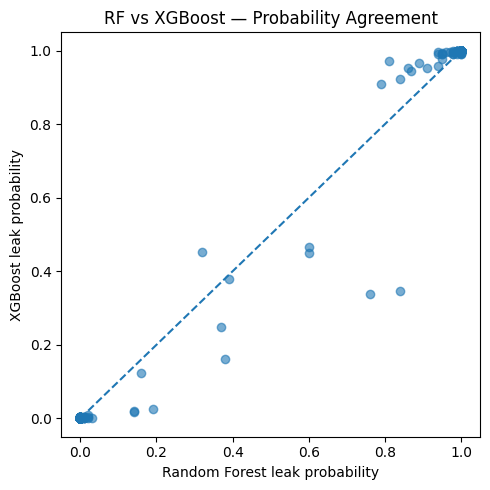

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/figures/holdout_probability_correlation.png


In [16]:
# ============================================================
# RF VS XGBOOST PROBABILITY CORRELATION
# ============================================================

plt.figure(figsize=(5, 5))

plt.scatter(
    error_df["rf_leak_probability"],
    error_df["xgboost_leak_probability"],
    alpha=0.6,
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("Random Forest leak probability")
plt.ylabel("XGBoost leak probability")
plt.title("RF vs XGBoost — Probability Agreement")
plt.tight_layout()

fig_path = FIGURE_DIR / "holdout_probability_correlation.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [17]:
# ============================================================
# MODEL SIZE AND TEST INFERENCE TIME
# ============================================================

def model_file_size_mb(path):
    return path.stat().st_size / (1024 * 1024)


def average_prediction_time(model, X, repeats=100):
    start = time.perf_counter()

    for _ in range(repeats):
        _ = model.predict_proba(X)[:, 1]

    end = time.perf_counter()

    total_time = end - start
    avg_time = total_time / repeats
    avg_time_per_sample_ms = (avg_time / len(X)) * 1000

    return avg_time, avg_time_per_sample_ms


rf_avg_batch_s, rf_avg_sample_ms = average_prediction_time(rf_model, X_test_rf)
xgb_avg_batch_s, xgb_avg_sample_ms = average_prediction_time(xgb_model, X_test_xgb)

efficiency_df = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Model Size MB": model_file_size_mb(RF_MODEL_PATH),
        "Avg Batch Time s": rf_avg_batch_s,
        "Avg Time per Window ms": rf_avg_sample_ms,
    },
    {
        "Model": "XGBoost",
        "Model Size MB": model_file_size_mb(XGB_MODEL_PATH),
        "Avg Batch Time s": xgb_avg_batch_s,
        "Avg Time per Window ms": xgb_avg_sample_ms,
    },
])

efficiency_display = efficiency_df.copy()
efficiency_display[
    ["Model Size MB", "Avg Batch Time s", "Avg Time per Window ms"]
] = efficiency_display[
    ["Model Size MB", "Avg Batch Time s", "Avg Time per Window ms"]
].round(6)

efficiency_path = TABLE_DIR / "model_size_and_inference_time.csv"
efficiency_display.to_csv(efficiency_path, index=False)

display(efficiency_display)

print("Saved:", efficiency_path)


,Model,Model Size MB,Avg Batch Time s,Avg Time per Window ms
0,Random Forest,0.369439,0.037837,0.076438
1,XGBoost,0.202600,0.003172,0.006409


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables/model_size_and_inference_time.csv


In [18]:
# ============================================================
# ABLATION RESULT COMPARISON
# ============================================================

RF_ABLATION_PATH = RF_TABLE_DIR / "rf_ablation_results.csv"
XGB_ABLATION_PATH = XGB_TABLE_DIR / "xgboost_ablation_results.csv"

rf_ablation = pd.read_csv(RF_ABLATION_PATH)
xgb_ablation = pd.read_csv(XGB_ABLATION_PATH)

rf_ablation["Model"] = "Random Forest"
xgb_ablation["Model"] = "XGBoost"

ablation_compare = pd.concat([rf_ablation, xgb_ablation], ignore_index=True)

ablation_compare_path = TABLE_DIR / "ablation_comparison.csv"
ablation_compare.to_csv(ablation_compare_path, index=False)

display(ablation_compare)

print("Saved:", ablation_compare_path)


,Experiment,N Features,CV Accuracy,CV F1,CV F1 Std,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC,Model
0,E1: Naive Mean Count,1,0.8127,0.8164,0.0913,0.8530,0.7657,0.7370,0.8419,0.7860,0.7633,0.6618,Random Forest
1,E2: Density Only,2,0.8625,0.8682,0.1031,0.8815,0.8283,0.7609,0.9684,0.8522,0.7884,0.6968,Random Forest
2,E3: E2 + Stability,5,0.9781,0.9784,0.0177,0.9976,0.9939,0.9960,0.9921,0.9941,0.9999,0.9999,Random Forest
3,E4: E3 + Geometry,7,0.9896,0.9900,0.0044,0.9985,0.9919,0.9960,0.9881,0.9921,0.9998,0.9998,Random Forest
4,E5: Full TUBLEX,11,0.9901,0.9904,0.0046,0.9986,0.9939,0.9960,0.9921,0.9941,0.9999,0.9999,Random Forest
5,E1: Naive Mean Count,1,0.8185,0.8301,0.1073,0.8104,0.8970,0.8582,0.9565,0.9047,0.8369,0.7015,XGBoost
6,E2: Density Only,2,0.8370,0.8488,0.1145,0.8317,0.7919,0.7131,0.9921,0.8298,0.8037,0.6676,XGBoost
7,E3: E2 + Stability,5,0.9876,0.9881,0.0058,0.9986,0.9899,0.9960,0.9842,0.9901,0.9998,0.9998,XGBoost
8,E4: E3 + Geometry,7,0.9886,0.9888,0.0048,0.9990,0.9879,0.9960,0.9802,0.9880,0.9998,0.9998,XGBoost
9,E5: Full TUBLEX,11,0.9916,0.9921,0.0053,0.9993,0.9859,0.9960,0.9763,0.9860,0.9998,0.9998,XGBoost


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/tables/ablation_comparison.csv


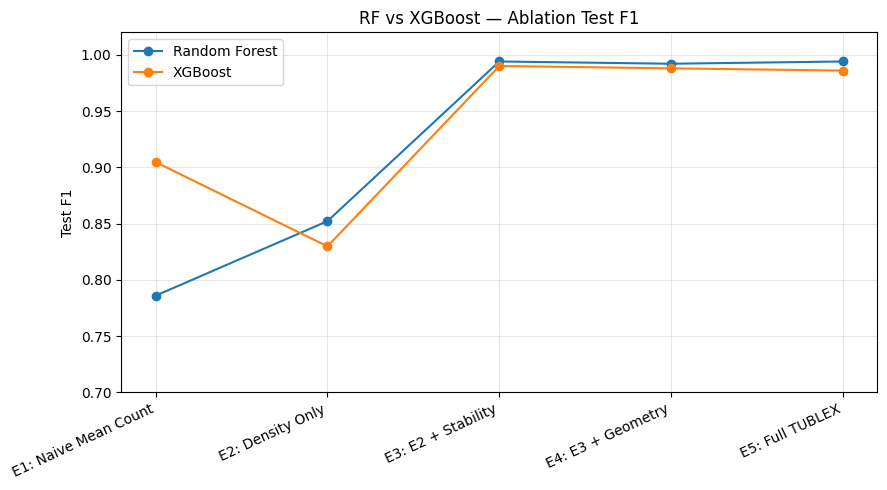

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/model_comparison/figures/ablation_test_f1_comparison.png


In [19]:
# ============================================================
# PLOT ABLATION F1 COMPARISON
# ============================================================

rf_plot = rf_ablation[["Experiment", "Test F1"]].copy()
xgb_plot = xgb_ablation[["Experiment", "Test F1"]].copy()

merged_ablation = rf_plot.merge(
    xgb_plot,
    on="Experiment",
    suffixes=("_RF", "_XGBoost"),
)

plt.figure(figsize=(9, 5))

plt.plot(
    merged_ablation["Experiment"],
    merged_ablation["Test F1_RF"],
    marker="o",
    label="Random Forest",
)

plt.plot(
    merged_ablation["Experiment"],
    merged_ablation["Test F1_XGBoost"],
    marker="o",
    label="XGBoost",
)

plt.xticks(rotation=25, ha="right")
plt.ylim(0.70, 1.02)
plt.ylabel("Test F1")
plt.title("RF vs XGBoost — Ablation Test F1")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

fig_path = FIGURE_DIR / "ablation_test_f1_comparison.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


## Conclusion

This notebook compares the selected Random Forest model and the XGBoost baseline on the same video-level hold-out test set.

Both models use the same 11 TUBLEX bubble descriptor features and the same test videos. The comparison includes final metrics, confusion matrices, ROC and precision-recall curves, prediction agreement, error overlap, probability disagreement, model size, inference time, and ablation context.

The Random Forest model is kept as the selected TUBLEX model, while XGBoost is retained as a strong comparative baseline. This separation keeps the repository clear: RF represents the final deployment-oriented model, while XGBoost supports the model-selection analysis.
